# Performing Sampling and Point Estimation

## 📚 Learning Objectives

By completing this notebook, you will:
- Perform sampling from populations
- Implement point estimation for population parameters
- Compare different sampling methods
- Evaluate estimator properties (bias, variance, consistency)

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — the Titanic manifest is itself a sample of a larger population; this notebook makes that explicit.

**Used later in:** Course 05 (AIAT 115) — Unit 5, lesson 07 "Large Dataset Handling" — sampling a file too big to hold down to a workable size.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Performing sampling and point estimation

---

## Introduction

**Sampling** involves selecting a subset from a population, and **point estimation** uses sample statistics to estimate population parameters.


---

## 📌 Real case: 2.4 million responses, and the wrong president

In 1936 *The Literary Digest* — a magazine with a good record of calling US presidential elections — mailed
straw ballots to about **ten million people** and received **2.38 million** back. On that basis it
predicted Alf Landon would win with **57.08% of the popular vote and 370 electoral votes**. Franklin
Roosevelt won **60.8%** of the popular vote and **523** electoral votes, losing only Maine and Vermont. The
Digest's margin was off by roughly **39 percentage points**, one of the largest polling failures ever
recorded.

The sample was not small. It was 2.38 million people. It was **wrong in a way no sample size can fix**. The
mailing list came from the magazine's own subscribers, automobile registrations and telephone directories —
groups with above-average incomes in the middle of the Great Depression. And the accepted modern analysis
puts even more weight on the second problem: **non-response bias**. People who strongly disliked Roosevelt
were more likely to bother returning the ballot. The failure is what created modern scientific polling.

**What goes wrong without this.** The standard error printed below falls like σ/√n, so more data always
looks like more accuracy. It is not. σ/√n measures how much your estimate *wobbles*; it says nothing about
whether it wobbles around the right value. Bias does not shrink with n — 2.38 million respondents produced
a 39-point error — and no confidence interval will ever tell you it is there.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy for the sampling, Matplotlib for plots, scipy.stats for reference
# distributions, and sklearn to load the real population we will sample from.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nPerforming Sampling and Point Estimation")
print("=" * 60)


✅ Libraries imported!

Performing Sampling and Point Estimation


## Part 1: Simple Random Sampling and Estimation


Part 1: Simple Random Sampling and Point Estimation

Population: median household income of every California census block group (1990)
  True mean (μ): 3.8707  (in units of $10,000)
  True std (σ): 1.8998
  Population size: 20640
  Skewness: 1.647  - real incomes have a long right tail

Sampling Results (n=100, 1000 samples):
  Mean of estimates: 3.8730
  Bias: 0.0023
  Std of mean estimates: 0.1955
  Theoretical standard error (σ/√n): 0.1900

  Std estimates - Mean: 1.8861
  Std estimates - Bias: -0.0137


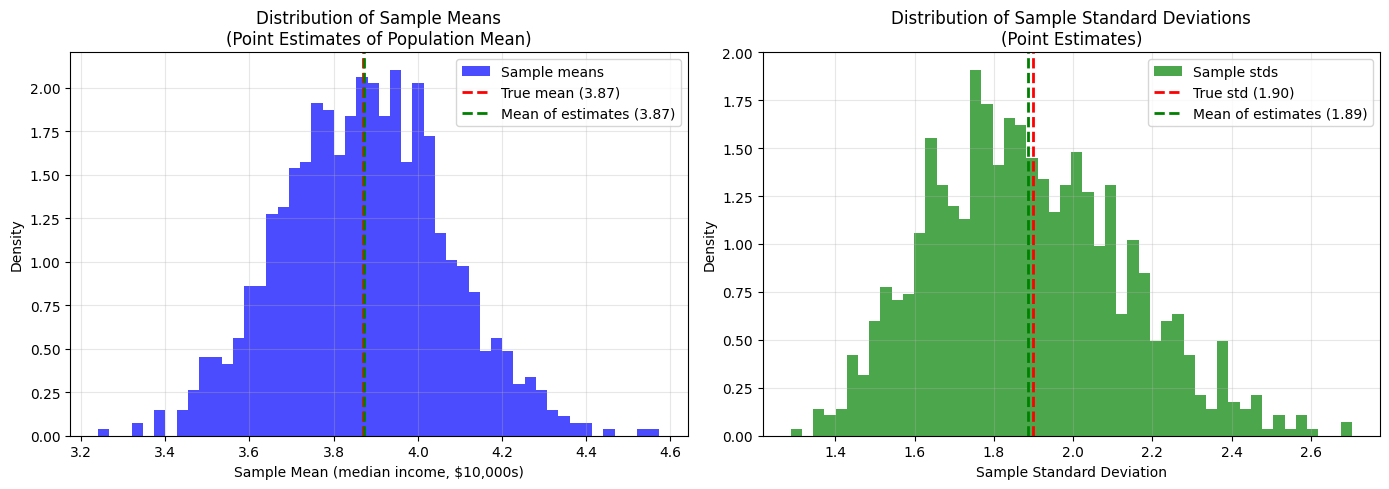


✅ Sampling and point estimation demonstrated on a real population!


In [2]:
# Point estimation in action on a REAL, fully observed population.
# The 1990 California census recorded a median household income for every one of its
# 20,640 block groups. Because we hold the WHOLE population, the "true" mean and std
# below are genuine population parameters - not numbers we made up.
# We then repeatedly draw small samples and use each sample's mean and std as estimates.
# Their spread around the truth IS the standard error.
# (The drawing is simulated on purpose - repeated sampling is the lesson here.)

print("=" * 60)
print("Part 1: Simple Random Sampling and Point Estimation")
print("=" * 60)

np.random.seed(42)

housing = fetch_california_housing()
population = housing.data[:, housing.feature_names.index("MedInc")]  # $10,000s
true_mean = population.mean()
true_std = population.std()

print(f"\nPopulation: median household income of every California census block group (1990)")
print(f"  True mean (μ): {true_mean:.4f}  (in units of $10,000)")
print(f"  True std (σ): {true_std:.4f}")
print(f"  Population size: {len(population)}")
print(f"  Skewness: {stats.skew(population):.3f}  - real incomes have a long right tail")

# Simple random sampling
sample_size = 100
n_samples = 1000

estimates_mean = []
estimates_std = []

# Each pass simulates one survey: sample 100 block groups, estimate once.
for _ in range(n_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)
    estimates_mean.append(sample.mean())  # Point estimate of mean
    estimates_std.append(sample.std(ddof=1))  # Point estimate of std (Bessel's correction)

estimates_mean = np.array(estimates_mean)
estimates_std = np.array(estimates_std)

print(f"\nSampling Results (n={sample_size}, {n_samples} samples):")
print(f"  Mean of estimates: {estimates_mean.mean():.4f}")
print(f"  Bias: {estimates_mean.mean() - true_mean:.4f}")
print(f"  Std of mean estimates: {estimates_mean.std():.4f}")
print(f"  Theoretical standard error (σ/√n): {true_std/np.sqrt(sample_size):.4f}")

print(f"\n  Std estimates - Mean: {estimates_std.mean():.4f}")
print(f"  Std estimates - Bias: {estimates_std.mean() - true_std:.4f}")

# Visualize
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(estimates_mean, bins=50, density=True, alpha=0.7, color='blue', label='Sample means')
plt.axvline(true_mean, color='r', linestyle='--', linewidth=2, label=f'True mean ({true_mean:.2f})')
plt.axvline(estimates_mean.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean of estimates ({estimates_mean.mean():.2f})')
plt.xlabel('Sample Mean (median income, $10,000s)')
plt.ylabel('Density')
plt.title('Distribution of Sample Means\n(Point Estimates of Population Mean)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(estimates_std, bins=50, density=True, alpha=0.7, color='green', label='Sample stds')
plt.axvline(true_std, color='r', linestyle='--', linewidth=2, label=f'True std ({true_std:.2f})')
plt.axvline(estimates_std.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean of estimates ({estimates_std.mean():.2f})')
plt.xlabel('Sample Standard Deviation')
plt.ylabel('Density')
plt.title('Distribution of Sample Standard Deviations\n(Point Estimates)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Sampling and point estimation demonstrated on a real population!")


## Part 2: Estimator Properties (Bias and Consistency)



Part 2: Estimator Properties (Bias and Consistency)

Sample size 10:
  Bias: -0.012271
  Variance: 0.357112
  MSE: 0.357263

Sample size 30:
  Bias: -0.021547
  Variance: 0.115090
  MSE: 0.115555



Sample size 50:
  Bias: -0.020894
  Variance: 0.063040
  MSE: 0.063477



Sample size 100:
  Bias: -0.000033
  Variance: 0.034654
  MSE: 0.034654

Sample size 200:
  Bias: 0.001425
  Variance: 0.017531
  MSE: 0.017533

Sample size 500:
  Bias: -0.003361
  Variance: 0.006763
  MSE: 0.006775


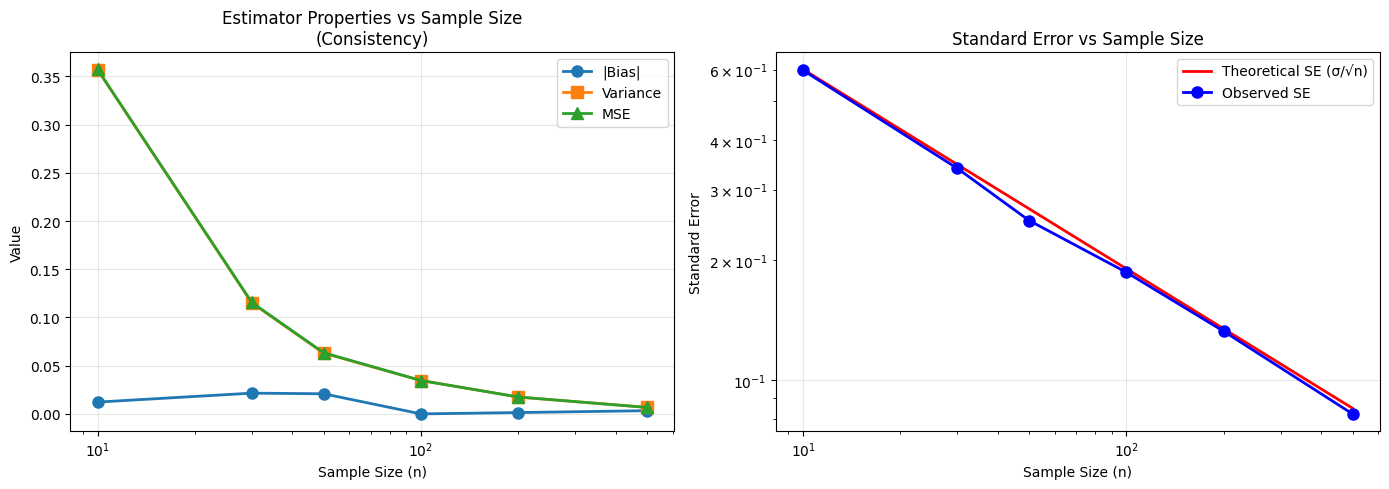


✅ Estimator properties (bias, variance, consistency) demonstrated!


In [3]:
# Consistency demo: repeat the estimation with growing sample sizes and track bias, variance, and MSE.
# Variance and MSE shrink toward zero at the σ/√n rate; the bias is already ~0 at every size,
# because the sample mean is an UNBIASED estimator - it wanders, but not in a fixed direction.
# Same real population as Part 1: all 20,640 California block groups.

print("\n" + "=" * 60)
print("Part 2: Estimator Properties (Bias and Consistency)")
print("=" * 60)

# Demonstrate consistency: estimator improves as sample size increases
sample_sizes = [10, 30, 50, 100, 200, 500]
n_samples = 500

bias_values = []
variance_values = []
mse_values = []

# For each sample size, rebuild the sampling distribution of the mean.
for n in sample_sizes:
    estimates = []
    for _ in range(n_samples):
        sample = np.random.choice(population, size=n, replace=False)
        estimates.append(sample.mean())
    estimates = np.array(estimates)
    
    bias = estimates.mean() - true_mean
    variance = estimates.var()
    mse = bias**2 + variance  # Mean Squared Error = Bias² + Variance
    
    bias_values.append(bias)
    variance_values.append(variance)
    mse_values.append(mse)
    
    print(f"\nSample size {n}:")
    print(f"  Bias: {bias:.6f}")
    print(f"  Variance: {variance:.6f}")
    print(f"  MSE: {mse:.6f}")

# Visualize consistency
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(sample_sizes, np.abs(bias_values), 'o-', label='|Bias|', linewidth=2, markersize=8)
plt.plot(sample_sizes, variance_values, 's-', label='Variance', linewidth=2, markersize=8)
plt.plot(sample_sizes, mse_values, '^-', label='MSE', linewidth=2, markersize=8)
plt.xlabel('Sample Size (n)')
plt.ylabel('Value')
plt.title('Estimator Properties vs Sample Size\n(Consistency)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.subplot(1, 2, 2)
plt.plot(sample_sizes, [true_std/np.sqrt(n) for n in sample_sizes], 'r-', label='Theoretical SE (σ/√n)', linewidth=2)
plt.plot(sample_sizes, [np.sqrt(v) for v in variance_values], 'bo-', label='Observed SE', linewidth=2, markersize=8)
plt.xlabel('Sample Size (n)')
plt.ylabel('Standard Error')
plt.title('Standard Error vs Sample Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()

print("\n✅ Estimator properties (bias, variance, consistency) demonstrated!")

---

## ⚠️ Where this breaks

- **Everything here measures variance, and the killer is bias.** The cells above draw *simple random
  samples* from a population held in full, so the printed bias is 0.0023 — essentially zero, exactly as
  theory says for the sample mean. Real samples are never drawn that way. Whoever answered the survey,
  whoever was admitted to the hospital, whoever's transaction reached your log: that is your sampling frame,
  and its bias is invisible to every formula on this page.
- **Theoretical and empirical standard errors agree because the assumptions hold.** 0.1955 measured against
  σ/√n = 0.1900 is a good match — and it is a match *because* the draws were independent and identically
  distributed from a known population. Break either condition (cluster sampling, repeated customers,
  time-correlated events) and the real spread is larger than the formula reports, usually by a lot.
- **"Unbiased" is a statement about the average over infinitely many repeats.** Look at the consistency
  table: at n = 10 the bias is −0.012 and at n = 30 it is −0.022 — the bias does not fall monotonically,
  because these are 1,000 finite simulations of an unbiased procedure. Any single sample can be far off.
  Unbiasedness is a property of the method, never a guarantee about your one dataset.
- **Cheaper alternative when you suspect the frame.** Rather than a bigger sample, spend the budget on
  stratifying (sample deliberately within known groups) or on measuring the non-responders. The Digest
  could have bought neither with another eight million ballots.


---

## 💬 Discuss

1. The Literary Digest had 2.38 million responses and was 39 points wrong. George Gallup called the same
   election correctly with a sample of about 50,000. Explain to a manager who insists "we need more data"
   what Gallup had that the Digest did not.
2. This notebook's bias is ~0 because the samples are drawn at random from a population we hold entirely.
   Take one dataset used elsewhere in this course and describe its sampling frame — who is in it, who is
   systematically missing, and what that would do to a model trained on it.
3. Non-response bias, not the mailing list, is now considered the main cause of the 1936 failure. What is
   the modern equivalent — whose data are you systematically not getting — for a Saudi mobile-app analytics
   pipeline?


## Summary

### Key Concepts:
1. **Sampling**: Selecting subset from population
2. **Point Estimation**: Using sample statistics to estimate parameters
3. **Bias**: Expected difference between estimate and true value
4. **Variance**: Spread of estimates around their mean
5. **Consistency**: Estimator improves as sample size increases
6. **MSE**: Mean Squared Error = Bias² + Variance

### Best Practices:
- Use unbiased estimators when possible
- Consider bias-variance tradeoff
- Larger samples reduce variance
- Use proper sampling methods (random, stratified, etc.)

### Applications:
- Population parameter estimation
- Statistical inference
- Quality control
- Survey analysis

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - Sampling and point estimation practical content

## 📚 References

1. Fisher, R. A. (1922). *On the Mathematical Foundations of Theoretical Statistics*. Philosophical Transactions of the Royal Society A, 222, 309–368.
2. Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*. The Annals of Statistics, 7(1), 1–26.
3. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/book1.html>